In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from tabulate import tabulate
from SQUIC_functions import *
from scipy import sparse

from collections import defaultdict
from scipy.sparse import coo_matrix, lil_matrix

In [15]:
def create_dataframe_and_matrix(csv_file_path, max_steps=365):
    # First pass: identify unique users and fraud accounts
    print("First pass: Identifying users and fraud accounts...")
    unique_users = set()
    fraud_accounts = set()
    
    chunk_size = 100000
    for chunk in pd.read_csv(csv_file_path, chunksize=chunk_size):
        # Get unique users
        orig_users = chunk['nameOrig'].dropna().unique()
        dest_users = chunk['nameDest'].dropna().unique()
        unique_users.update(orig_users)
        unique_users.update(dest_users)
        
        # Identify fraud accounts
        fraud_rows = chunk[chunk['isFraud'] == 1]
        fraud_accounts.update(fraud_rows['nameOrig'].dropna())
        fraud_accounts.update(fraud_rows['nameDest'].dropna())
        
        del chunk
    
    unique_users = sorted(list(unique_users))
    print(f"Found {len(unique_users)} unique users")
    print(f"Found {len(fraud_accounts)} fraud accounts")
    
    # Create user-to-id mapping
    user_to_id = {user: i for i, user in enumerate(unique_users)}
    max_account_id = len(unique_users)
    
    # Initialize DataFrame for balances
    df = pd.DataFrame(index=range(max_steps), columns=unique_users, dtype=float)
    
    # Initialize transaction tracking
    edge_weights = defaultdict(float)
    
    # Track which users we've seen for balance tracking
    user_first_seen = {}
    
    print("Second pass: Processing transactions and building matrices...")
    
    # Second pass: populate DataFrame and build transaction matrix
    for chunk in pd.read_csv(csv_file_path, chunksize=chunk_size):
        for _, row in chunk.iterrows():
            step = int(row['step'])
            amount = float(row['amount'])
            
            # Get users
            orig_user = row['nameOrig']
            dest_user = row['nameDest']
            
            # Build transaction matrix (only if both users are valid)
            if orig_user in user_to_id and dest_user in user_to_id:
                i = user_to_id[orig_user]
                j = user_to_id[dest_user]
                edge_weights[(i, j)] += amount
            
            # Process origin user for balance DataFrame
            old_balance = float(row['oldBalanceOrig'])
            new_balance = float(row['newBalanceOrig'])
                
            if orig_user not in user_first_seen:
                # First time seeing this user - backfill with old balance
                if step > 0:
                    df.loc[:step-1, orig_user] = old_balance
                user_first_seen[orig_user] = True
                
            # Update from current step onwards
            df.loc[step:, orig_user] = new_balance
            
            # Process destination user for balance DataFrame
            old_balance = float(row['oldBalanceDest'])
            new_balance = float(row['newBalanceDest'])
                
            if dest_user not in user_first_seen:
                # First time seeing this user - backfill with old balance
                if step > 0:
                    df.loc[:step-1, dest_user] = old_balance
                user_first_seen[dest_user] = True
                
            # Update from current step onwards
            df.loc[step:, dest_user] = new_balance
        
        del chunk
    
    # Convert edge_weights dict to sparse matrix
    print("Converting transaction data to sparse matrix...")
    rows, cols, data = zip(*[(i, j, amt) for (i, j), amt in edge_weights.items()])
    transaction_matrix = coo_matrix((data, (rows, cols)), 
                                      shape=(max_account_id, max_account_id)).tolil()
   
    # Create account properties dictionary
    account_prop = {
        i: {
            "original_id": user,
            "fraud": user in fraud_accounts,
            "class": str(user)[0]  # 'C', 'M', or 'B'
        }
        for i, user in enumerate(unique_users)
    }
    
    print(f"Balance DataFrame shape: {df.shape}")
    print(f"Transaction matrix shape: {transaction_matrix.shape}")
    print(f"Transaction matrix nnz (non-zero elements): {transaction_matrix.nnz}")
    
    return df, account_prop, transaction_matrix

In [16]:
df, account_prop, transaction_matrix = create_dataframe_and_matrix("rawLog.csv", max_steps=365)

First pass: Identifying users and fraud accounts...
Found 111 unique users
Found 24 fraud accounts
Second pass: Processing transactions and building matrices...
Converting transaction data to sparse matrix...
Balance DataFrame shape: (365, 111)
Transaction matrix shape: (111, 111)
Transaction matrix nnz (non-zero elements): 1566


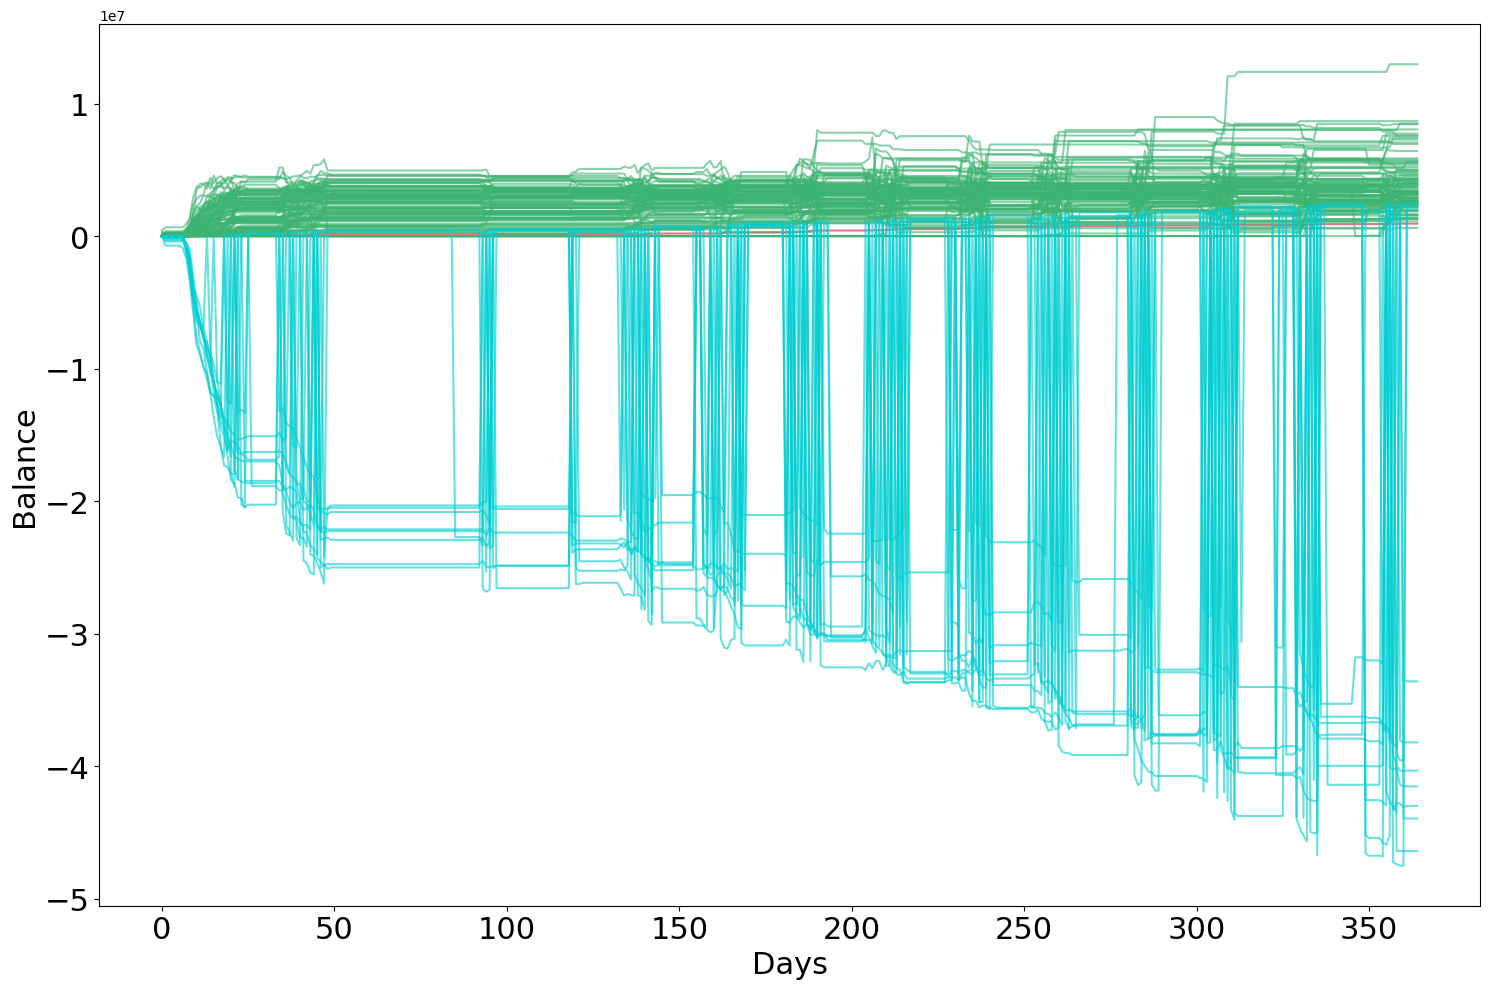

In [17]:
# Plot the balance evolution for all users (columns) as separate lines
# plt.figure(figsize=(15,10), dpi= 300)
plt.figure(figsize=(15,10))

# Plot each column (account balance) as a line
for user in df.columns:
    if user.startswith('C'):
        color = 'mediumseagreen'
    elif user.startswith('B'):
        color = 'crimson'
    else:
        color = 'darkturquoise'
    plt.plot(df.index, df[user], color=color, label=f"User {user}", alpha=0.6)

# Add title and labels
plt.xlabel("Days", fontsize=22)
plt.ylabel("Balance", fontsize=22)

# Rotate x-axis labels for better visibility
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)

# Display the plot
plt.tight_layout()
plt.show()

In [19]:
Y = df.T.values

In [20]:
# Compute std dev per row
row_std = np.std(Y, axis=1, keepdims=True)

# Avoid division by zero
row_std[row_std == 0] = 1.0

# Normalize each row
Y_new = Y / row_std

In [21]:
print("NaNs?", np.isnan(Y_new).any())
print("Infs?", np.isinf(Y_new).any())
print("Max:", np.max(Y_new))
print("Min:", np.min(Y_new))
print("Mean std per row (should be 1):", round(np.mean(np.std(Y_new, axis=1)), 2))

NaNs? False
Infs? False
Max: 8.050641823275443
Min: -3.269078107171305
Mean std per row (should be 1): 1.0


In [22]:
l = [0.99999, 0.9999, 0.999, 0.995, 0.992, 0.99]

In [23]:
Theta_dict = {}

In [24]:
ROWS = Y_new.shape[0]
ROWS

111

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999900e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=2.69e-03 nnz(S)/p=1.00e+00
* iter=1 time=2.67e-03 obj=1.28e+03 |delta(obj)|/obj=9.13e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* iter=2 time=1.18e-03 obj=1.20e+03 |delta(obj)|/obj=6.41e-02 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* iter=3 time=1.30e-03 obj=1.12e+03 |delta(obj)|/ob

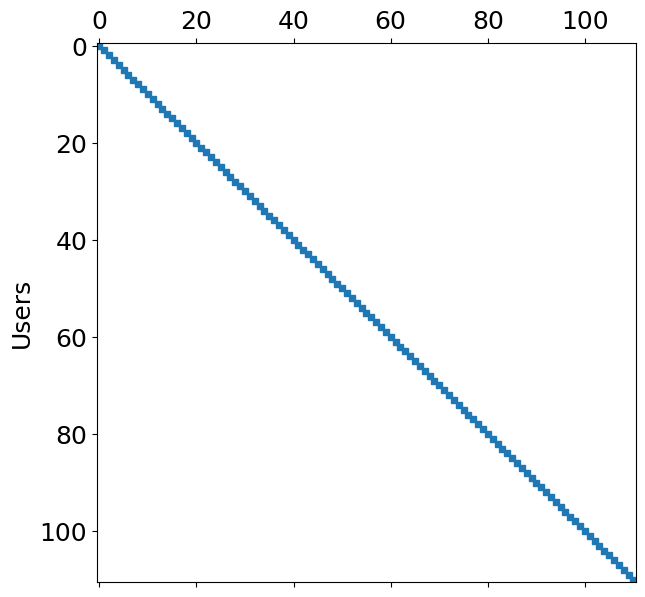

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.54e-04 nnz(S)/p=1.00e+00
* iter=1 time=9.14e-04 obj=1.02e+03 |delta(obj)|/obj=8.91e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* iter=2 time=1.29e-03 obj=9.45e+02 |delta(obj)|/obj=8.13e-02 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* iter=3 time=1.40e-03 obj=8.69e+02 |delta(obj)|/ob

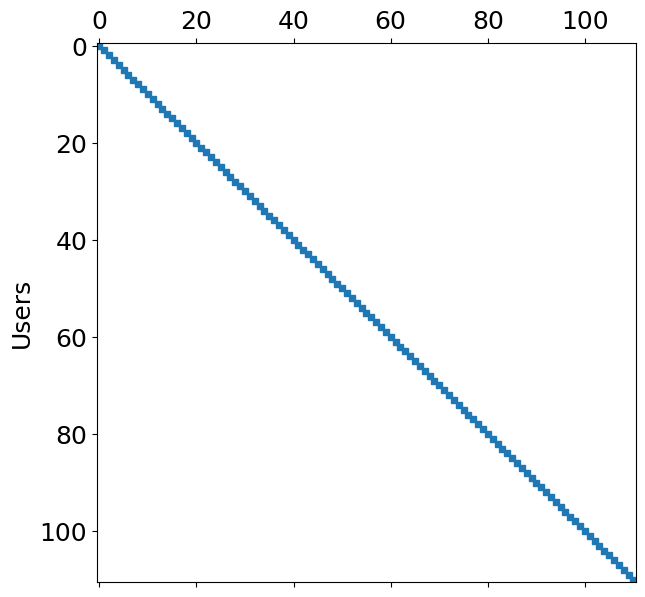

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.990000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.75e-04 nnz(S)/p=1.00e+00
* iter=1 time=8.20e-04 obj=7.67e+02 |delta(obj)|/obj=8.55e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* iter=2 time=1.22e-03 obj=6.90e+02 |delta(obj)|/obj=1.11e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* iter=3 time=1.44e-03 obj=6.14e+02 |delta(obj)|/ob

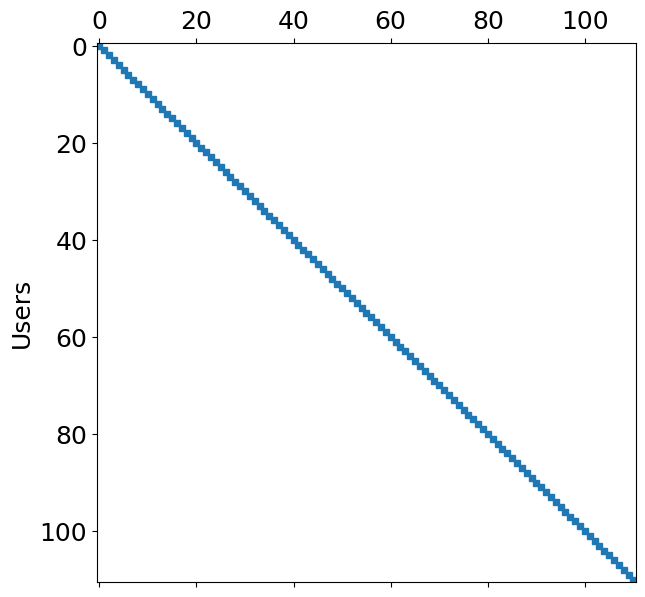

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.950000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.93e-04 nnz(S)/p=1.00e+00
* iter=1 time=8.21e-04 obj=5.89e+02 |delta(obj)|/obj=8.12e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* iter=2 time=1.22e-03 obj=5.14e+02 |delta(obj)|/obj=1.46e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* iter=3 time=1.67e-03 obj=4.40e+02 |delta(obj)|/ob

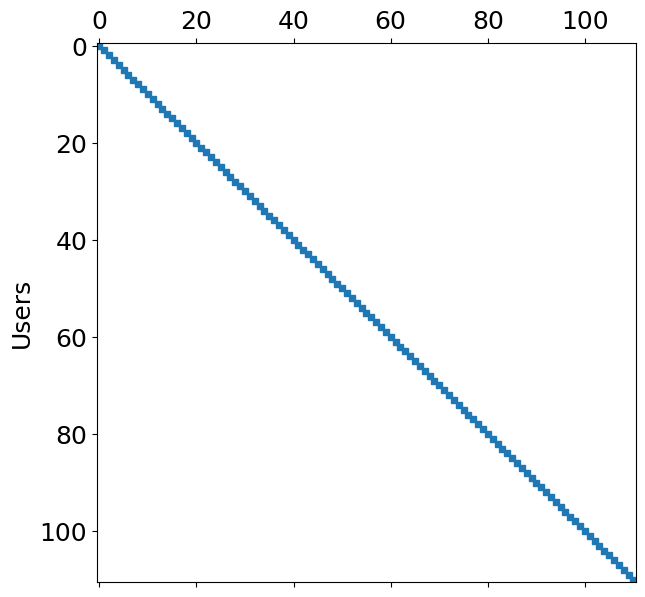

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.920000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.87e-04 nnz(S)/p=1.00e+00
* iter=1 time=8.80e-04 obj=5.38e+02 |delta(obj)|/obj=7.94e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* iter=2 time=1.21e-03 obj=4.63e+02 |delta(obj)|/obj=1.60e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* iter=3 time=1.33e-03 obj=3.92e+02 |delta(obj)|/ob

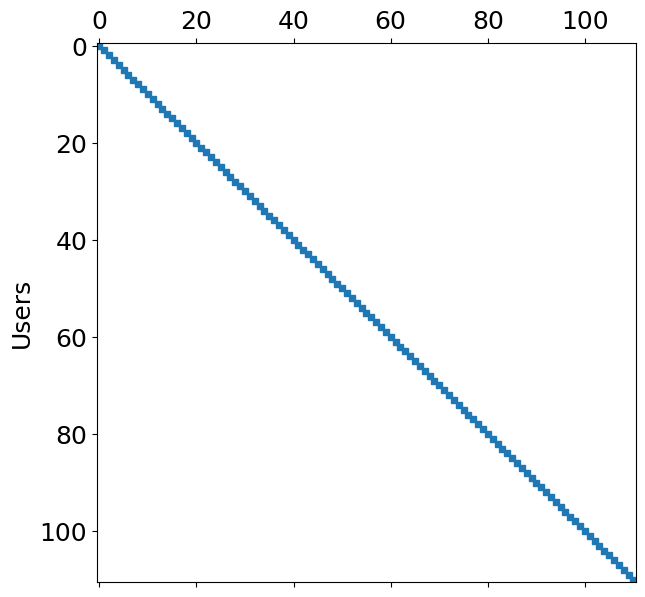

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.900000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.16e-04 nnz(S)/p=1.00e+00
* iter=1 time=9.17e-04 obj=5.13e+02 |delta(obj)|/obj=7.84e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* iter=2 time=1.38e-03 obj=4.40e+02 |delta(obj)|/obj=1.68e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* iter=3 time=1.40e-03 obj=3.69e+02 |delta(obj)|/ob

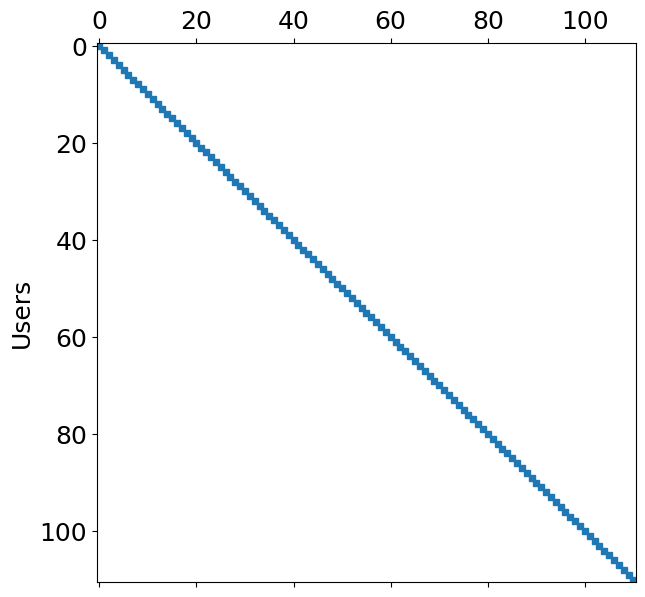

In [25]:
data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    Theta, _, computation_time = compute_squic(Y_new, rho)
    computation_time = round(computation_time, 2)
    print(f"time required: {computation_time} seconds")

    Theta = sparse.csr_matrix(Theta) # store Theta as sparse
    Theta_dict[rho] = Theta

    nonz, nonz_r = nnz_sparse(Theta_dict[rho], ROWS)

    print("Checking if symmetric")
    if check_symmetric_sparse(Theta_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append('Yes')
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append('No')

    data_nnz.append(nonz)
    data_nnzr.append(nonz_r)
    data_time.append(computation_time)

    if nonz == ROWS:
        print(f"For rho = {rho} just element on the diagonal")
        print_matrix(Theta_dict[rho])
    elif nonz == ROWS * ROWS:
        print(f"For rho = {rho} big dense matrix")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        print_matrix(Theta_dict[rho])
    else:
        print(f"For rho = {rho} there are some nnz")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        print_matrix(Theta_dict[rho])


table_squic_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]

# SQUIC-Fit


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.763964e+01
 Y:         111 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999900e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=1.00e+00 time=7.38e-04
* iter=1 time=9.28e-04 obj=1.28e+03 |delta(obj)|/obj=9.13e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* iter=2 time=3.31e-03 obj=1.20e+03 |delta(obj)|/obj=6.41e-02 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* iter=3 time=3.45e-03 obj=1.12e+03 |de

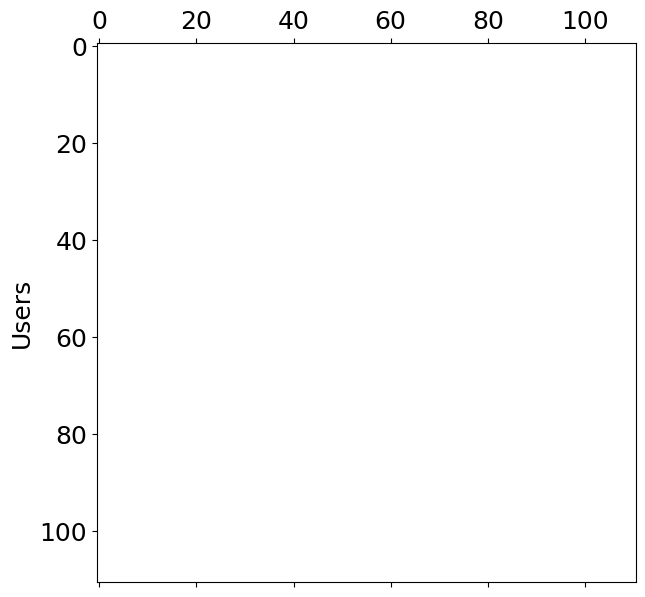

✅ Matrix is symmetric per rho 0.99999

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.763964e+01
 Y:         111 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=1.00e+00 time=4.69e-04
* iter=1 time=8.14e-04 obj=1.02e+03 |delta(obj)|/obj=8.91e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* iter=2 time=1.24e-03 obj=9.45e+02 |delta(obj)|/obj=8.13e-02 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
*

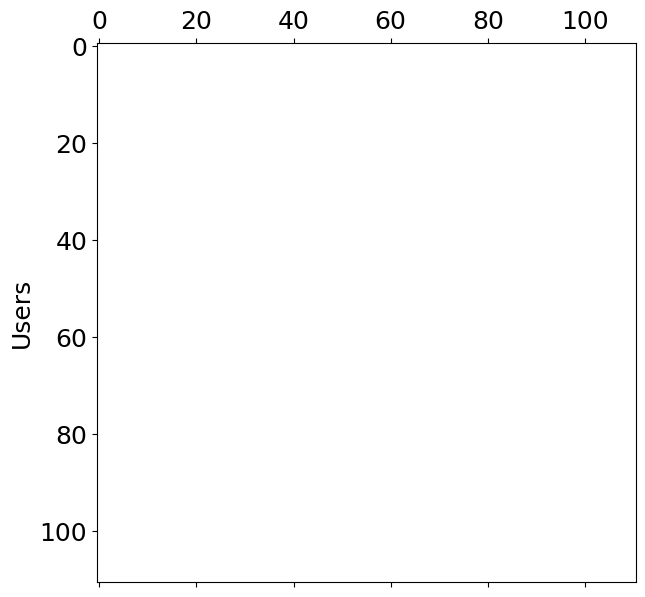

✅ Matrix is symmetric per rho 0.9999

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.763964e+01
 Y:         111 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.990000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=1.00e+00 time=4.43e-04
* iter=1 time=8.07e-04 obj=7.67e+02 |delta(obj)|/obj=8.55e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* iter=2 time=1.26e-03 obj=6.90e+02 |delta(obj)|/obj=1.11e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* 

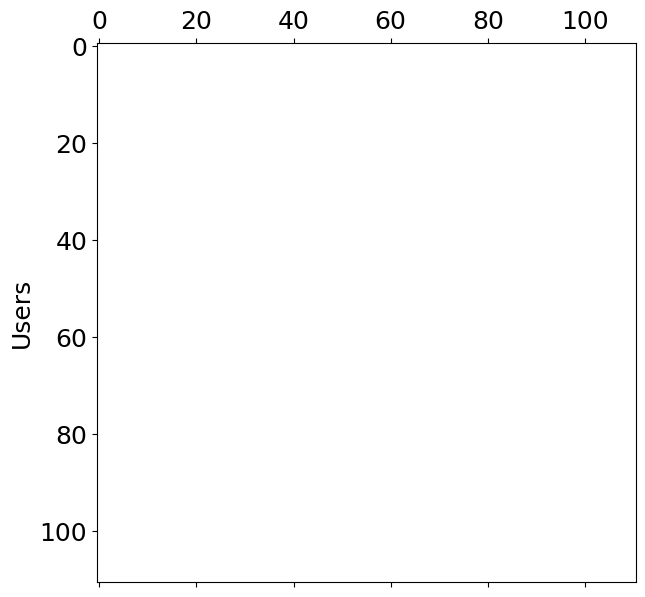

✅ Matrix is symmetric per rho 0.999

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.763964e+01
 Y:         111 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.950000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=1.00e+00 time=5.57e-04
* iter=1 time=7.64e-04 obj=5.89e+02 |delta(obj)|/obj=8.12e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* iter=2 time=1.18e-03 obj=5.14e+02 |delta(obj)|/obj=1.46e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* i

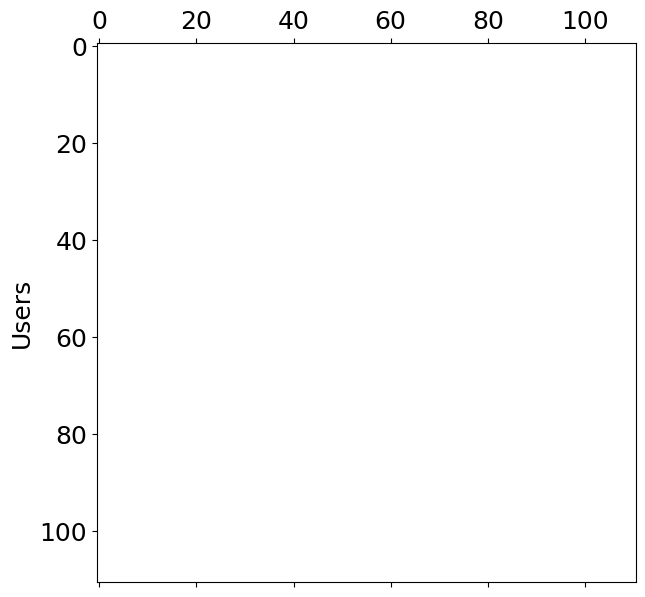

✅ Matrix is symmetric per rho 0.995

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.763964e+01
 Y:         111 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.920000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=1.00e+00 time=4.61e-04
* iter=1 time=9.49e-04 obj=5.38e+02 |delta(obj)|/obj=7.94e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* iter=2 time=1.20e-03 obj=4.63e+02 |delta(obj)|/obj=1.60e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* i

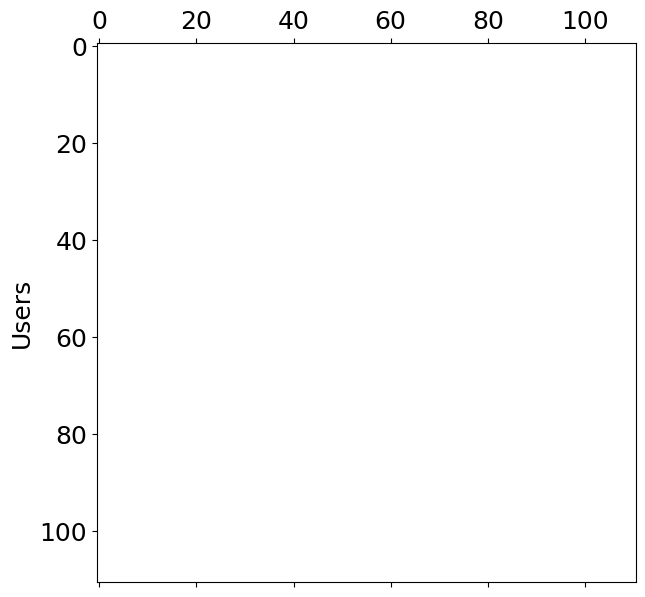

✅ Matrix is symmetric per rho 0.992

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.763964e+01
 Y:         111 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.900000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=1.00e+00 time=7.15e-04
* iter=1 time=7.68e-04 obj=5.13e+02 |delta(obj)|/obj=7.84e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* iter=2 time=1.18e-03 obj=4.40e+02 |delta(obj)|/obj=1.68e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
* i

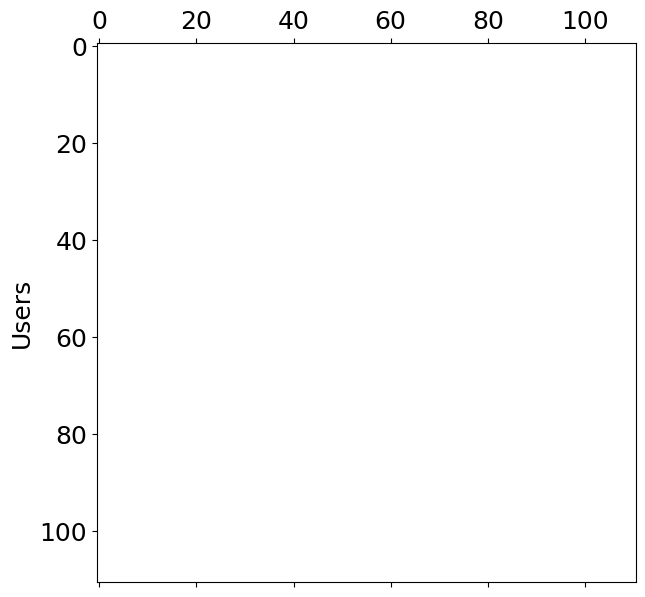

✅ Matrix is symmetric per rho 0.99


In [26]:
W_dict = {}

data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    W, end_time = squic_fit_matrix_sparse(Y_new, l=rho, matrix=transaction_matrix)
    W_dict[rho] = sparse.csr_matrix(W)
    end_time = round(end_time, 2)
    print(f"required time: {end_time}")

    nnz, nnz_r = nnz_sparse(W_dict[rho], ROWS)
    print(f"nnz = {nnz} per rows = {nnz_r}")

    print_matrix(W_dict[rho])

    if check_symmetric_sparse(W_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append("Yes")
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append("No")

    data_nnz.append(nnz)
    data_nnzr.append(nnz_r)
    data_time.append(end_time)

table_fit_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]


In [27]:
from tabulate import tabulate

In [28]:
def table(data, title, l):
    table = tabulate(
        data,
        headers=[title] + l,
        tablefmt="fancy_grid",
        numalign="center",
        stralign="center"
    )
    return table

In [29]:
print(table(table_squic_norm, "SQUIC NORM", l))

print(table(table_fit_norm, "SQUIC FIT NORM", l))

╒══════════════╤═══════════╤══════════╤═════════╤═════════╤═════════╤════════╕
│  SQUIC NORM  │  0.99999  │  0.9999  │  0.999  │  0.995  │  0.992  │  0.99  │
╞══════════════╪═══════════╪══════════╪═════════╪═════════╪═════════╪════════╡
│     NNZ      │    111    │   111    │   111   │   111   │   111   │  111   │
├──────────────┼───────────┼──────────┼─────────┼─────────┼─────────┼────────┤
│   NNZ/Row    │    1.0    │   1.0    │   1.0   │   1.0   │   1.0   │  1.0   │
├──────────────┼───────────┼──────────┼─────────┼─────────┼─────────┼────────┤
│   Time (s)   │   0.03    │   0.02   │  0.02   │  0.02   │  0.01   │  0.01  │
├──────────────┼───────────┼──────────┼─────────┼─────────┼─────────┼────────┤
│  Symmetric   │    Yes    │   Yes    │   Yes   │   Yes   │   Yes   │  Yes   │
╘══════════════╧═══════════╧══════════╧═════════╧═════════╧═════════╧════════╛
╒══════════════════╤═══════════╤══════════╤═════════╤═════════╤═════════╤════════╕
│  SQUIC FIT NORM  │  0.99999  │  0.9999  │  0.9